# Regression with scikit-learn

**Objective:** Train and evaluate regression models using the California Housing dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

display(X.head())
print("Shape:", X.shape)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Shape: (20640, 8)


## 1. Train/test split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16512, 8)
Test: (4128, 8)


## 2. Linear regression with feature scaling

In [3]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)
pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
R²:   0.5758


## 3. Polynomial regression

In [4]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)

print("Polynomial R²:", r2_score(y_test, poly_pred))
print("Polynomial MAE:", mean_absolute_error(y_test, poly_pred))

Polynomial R²: 0.645681972926207
Polynomial MAE: 0.4670009334696577


## 4. Actual vs predicted

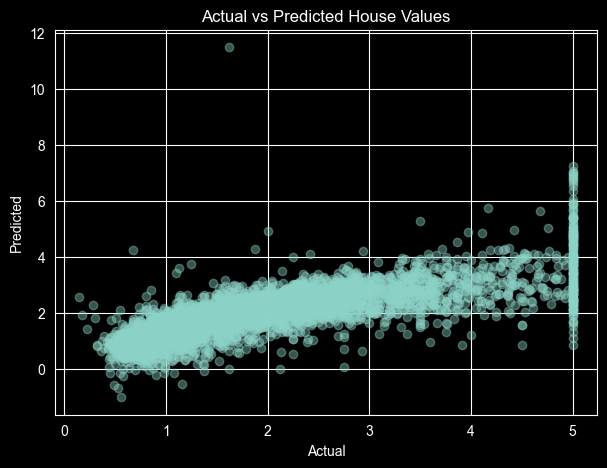

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted House Values")
plt.show()

## 5. Interpretation

In [6]:
print("The model predicts a continuous numeric target.")
print("MAE represents average absolute prediction error.")
print("MSE penalizes larger errors more strongly.")
print("R² measures the proportion of target variance explained by the model.")
print("The train/test split provides an estimate of generalization performance.")

The model predicts a continuous numeric target.
MAE represents average absolute prediction error.
MSE penalizes larger errors more strongly.
R² measures the proportion of target variance explained by the model.
The train/test split provides an estimate of generalization performance.
